In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

from decoder_quant import (
    # mask_decoder_monkey_patch, 
    inference_image,
    re_cal_attn,
    TwoWayTransformerObserver,
) 
from utils import get_activation_boxplot, to_numpy
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt
# from quant_utils import SignProcessor, DoNothingProcessor, AttnBasedProcessor
from segment_anything.modeling.transformer import TwoWayAttentionBlock, TwoWayTransformer, Attention

from decoder_observer import mask_decoder_monkey_patch,TwoWayTransformerObserverElementLow



/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWar

In [5]:
model_type = 'vit_l'
checkpoint_path= './pretrained_checkpoint/sam_hq_vit_l.pth'
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')


# predictor = SamPredictor(sam)
# processor = AttnBasedProcessor('attn') 
# # processor = DoNothingProcessor('attn') 
# # processor = SignProcessor('attn') 
# processor.calibrate(
#     predictor=predictor, 
#     modules=(TwoWayTransformer),
#     num_samples=1,
# )
processor = None
predictor = SamPredictor(sam)
mask_decoder_monkey_patch(predictor.model, processor, n_bits=8, debug=True, high_element= True)


/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/build_sam.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = tor

<All keys matched successfully>


0
(1024, 1024, 3)


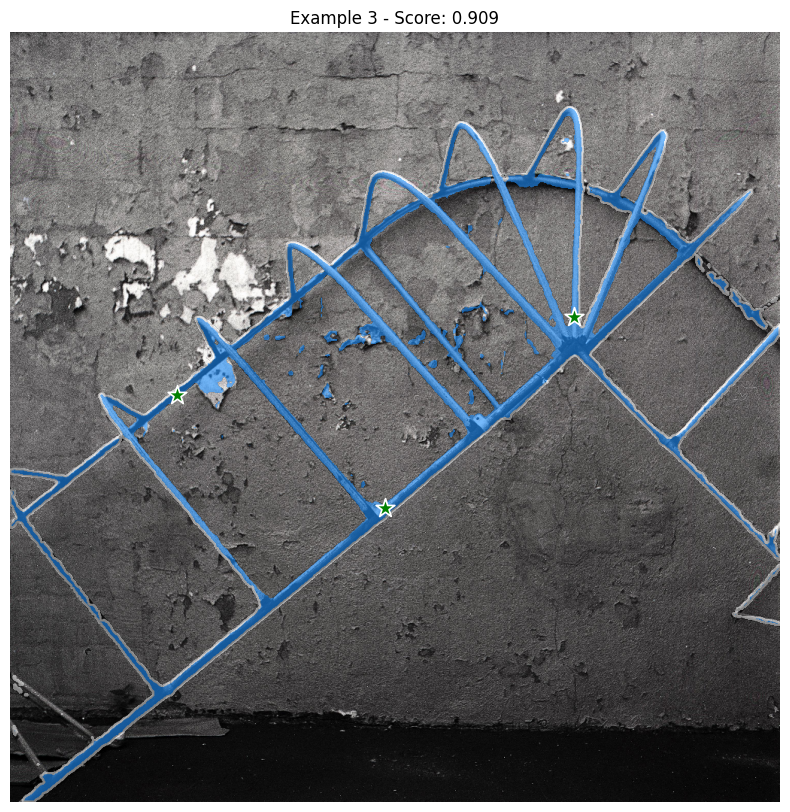

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]]),
 array([0.90871847], dtype=float32),
 array([[[-13.3659115, -12.893103 , -12.484683 , ..., -11.6002865,
          -13.034973 , -13.001036 ],
         [-13.658445 , -12.482525 , -13.358051 , ..., -12.867996 ,
          -12.84037  , -12.743578 ],
         [-15.43568  , -14.429378 , -16.146126 , ..., -11.439121 ,
          -10.208031 , -10.982714 ],
         ...,
         [ -9.698236 ,  -7.5889225, -10.531946 , ..., -13.281596 ,
          -13.416828 , -13.377311 ],
         [ -9.341847 ,  -6.691853 ,  -8.654046 , ..., -11.6151085,
          -12.688192 , -12.525857 ],
         [ -8.603276 ,  -6.4845138,  -5.465893 , ..., -11.611011

In [6]:
# results = inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)
# for i in range(5):
print(len(TwoWayTransformerObserverElementLow.attention_score['p2i_attn']))
inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)

## LOW High ELEMENT

In [7]:
x = TwoWayTransformerObserverElementLow.attention_score[f'p2i_O']
x_ha = TwoWayTransformerObserverElementLow.attention_score[f'p2i_O_qha']
x_full = TwoWayTransformerObserverElementLow.attention_score[f'p2i_O_qfull']
print(len(x), len(x_ha), len(x_full))
print(x[0].shape, x_ha[0].shape, x_full[0].shape)


4 4 4
torch.Size([1, 8, 10, 16]) torch.Size([1, 8, 10, 16]) torch.Size([1, 8, 10, 16])


In [8]:
def get_p2p_O(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'p2p_O'][layer_idx]
    return x

def get_p2p_O_qha(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'p2p_O_qha'][layer_idx]
    return x

def get_p2p_O_qfull(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'p2p_O_qfull'][layer_idx]
    return x

def get_p2i_O(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'p2i_O'][layer_idx]
    return x

def get_p2i_O_qha(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'p2i_O_qha'][layer_idx]
    return x

def get_p2i_O_qfull(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'p2i_O_qfull'][layer_idx]
    return x

def get_i2p_O(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'i2p_O'][layer_idx]
    return x

def get_i2p_O_qha(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'i2p_O_qha'][layer_idx]
    return x

def get_i2p_O_qfull(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'i2p_O_qfull'][layer_idx]
    return x

def get_final_O(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'final_O'][layer_idx]
    return x

def get_final_O_qha(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'final_O_qha'][layer_idx]
    return x

def get_final_O_qfull(layer_idx: int):
    x = TwoWayTransformerObserverElementLow.attention_score[f'final_O_qfull'][layer_idx]
    return x

In [17]:
import numpy as np

norm_high_total = 0
norm_full_total = 0
for i in range(2,4):
    layer_idx=i
    O_origin = get_i2p_O(layer_idx).cpu().numpy()
    O_qha = get_i2p_O_qha(layer_idx).cpu().numpy()
    O_qfull = get_i2p_O_qfull(layer_idx).cpu().numpy()
    # print("O_origin:", O_origin.shape)
    # print("O_qha:", O_qha.shape)
    # print("O_qfull:", O_qfull.shape)

    diff_h = O_origin - O_qha
    diff_f = O_origin - O_qfull
    norm_high = np.linalg.norm(diff_h)
    norm_full = np.linalg.norm(diff_f)
    norm_high_total += norm_high
    norm_full_total += norm_full
    ratio = norm_high / norm_full 
    print("layer:", i, "ratio: ",ratio)
norm_high_total /=2
norm_full_total /=2
print("norm_high_total:", norm_high_total)
print("norm_full_total:", norm_full_total)
ratio = norm_high_total / norm_full_total
print(ratio)

layer: 2 ratio:  0.7129122
layer: 3 ratio:  0.82576865
norm_high_total: 48.71420955657959
norm_full_total: 61.80013465881348
0.7882541005051408


In [18]:
import numpy as np

norm_high_total = 0
norm_full_total = 0
for i in range(2):
    layer_idx=i
    O_origin = get_i2p_O(layer_idx).cpu().numpy()
    O_qha = get_i2p_O_qha(layer_idx).cpu().numpy()
    O_qfull = get_i2p_O_qfull(layer_idx).cpu().numpy()
    # print("O_origin:", O_origin.shape)
    # print("O_qha:", O_qha.shape)
    # print("O_qfull:", O_qfull.shape)

    diff_h = O_origin - O_qha
    diff_f = O_origin - O_qfull
    norm_high = np.linalg.norm(diff_h)
    norm_full = np.linalg.norm(diff_f)
    norm_high_total += norm_high
    norm_full_total += norm_full
    ratio = norm_high / norm_full 
    print("layer:", i, "ratio: ",ratio)
norm_high_total /=2
norm_full_total /=2
print("norm_high_total:", norm_high_total)
print("norm_full_total:", norm_full_total)
ratio = norm_high_total / norm_full_total
print(ratio)

layer: 0 ratio:  0.43449208
layer: 1 ratio:  0.4939361
norm_high_total: 29.30416202545166
norm_full_total: 61.80013465881348
0.47417634584834223


##########################

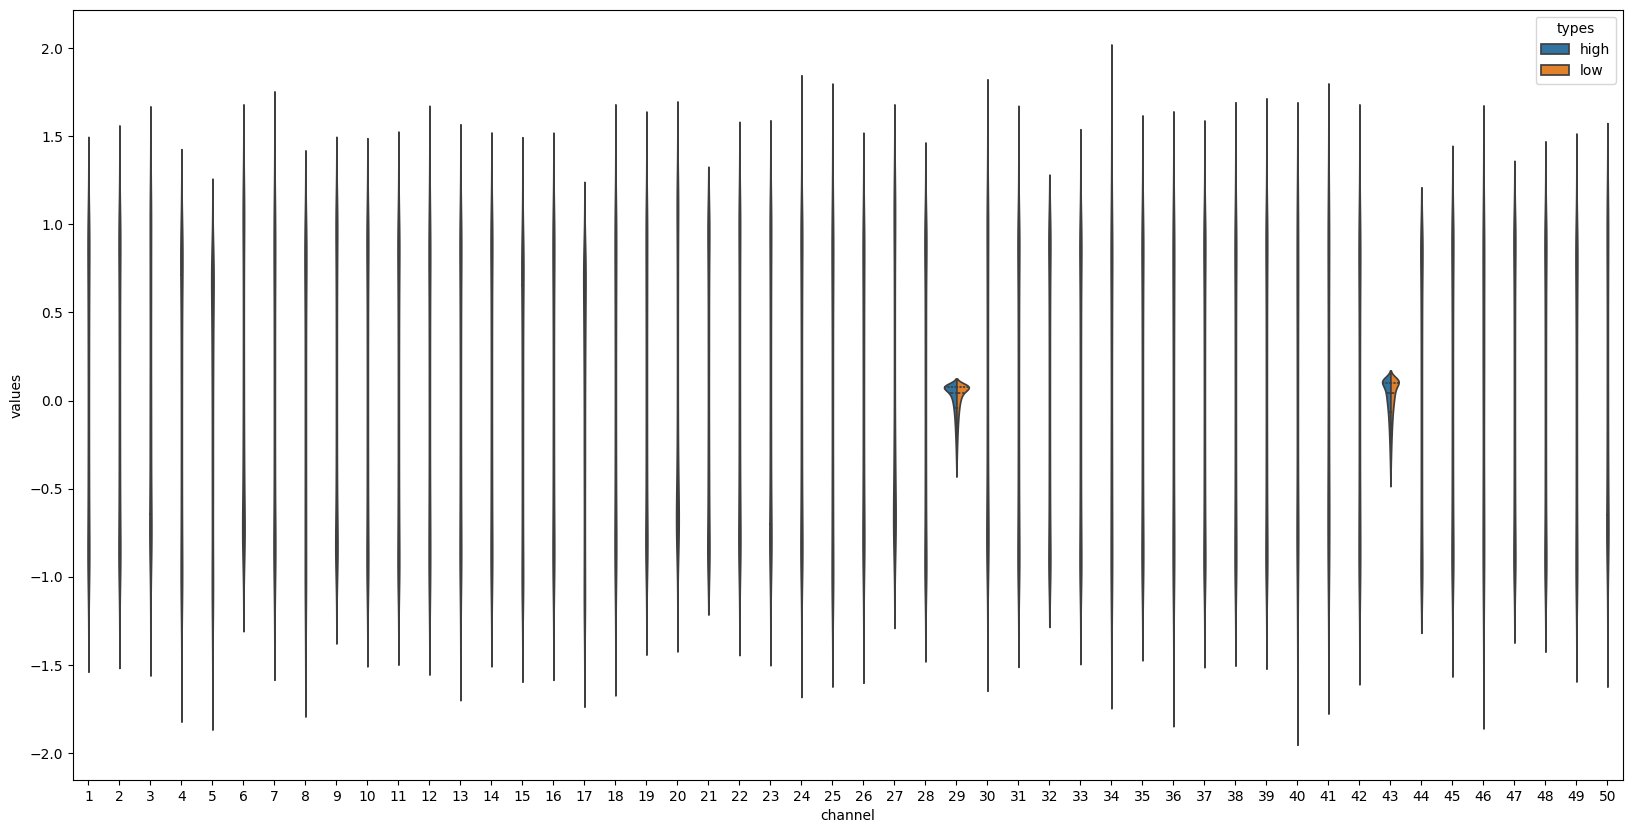

In [ ]:
pre_i = TwoWayTransformerObserver.attention_score["p2i_k_pre"][0]
pre_p  = TwoWayTransformerObserver.attention_score["p2i_q_pre"][0]
fig, ax= plt.subplots(1,1, figsize=(20,10))

get_activation_boxplot(high_activations=pre_i-pre_i.mean(1,keepdim=True), low_activations=pre_i-pre_i.mean(1, keepdim=True), ax=ax, offset=200, max_channels=50,token_wise=False)



In [ ]:
weights = TwoWayTransformerObserver.extract_weights(predictor.model)

torch.Size([1, 4096, 256])


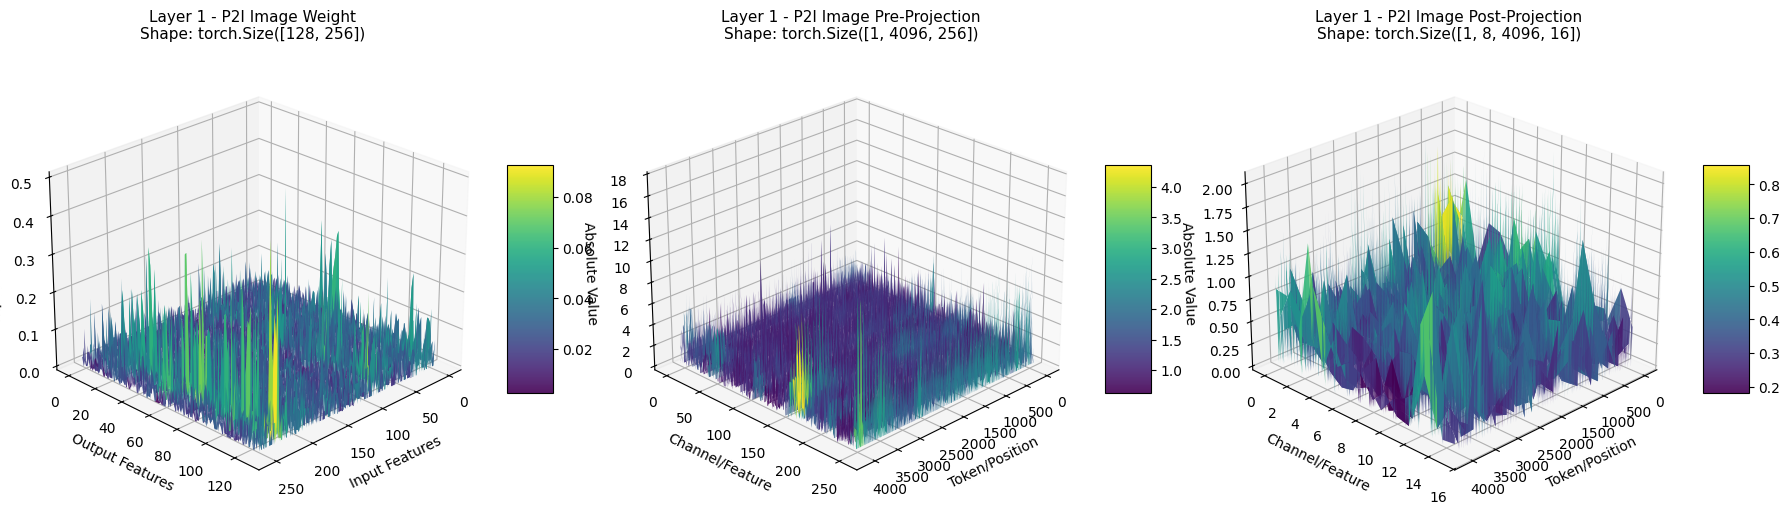

In [12]:
from decoder_quant import TwoWayTransformerObserver
from utils import plot_weight_activation_comparison

# After running inference with decoder_quant.py

# Extract weights once
weights = TwoWayTransformerObserver.extract_weights(predictor.model)

# Get activations for layer 0, p2i (point-to-image) Q projection
layer_idx = 1
q_weight = TwoWayTransformerObserver.weights[f"p2i_k_w_layer{layer_idx}"]
q_pre = TwoWayTransformerObserver.attention_score["p2i_k_pre"][layer_idx]
q_post = TwoWayTransformerObserver.attention_score["p2i_k"][layer_idx]
# q_weight = TwoWayTransformerObserver.weights[f"final_k_w"]
# q_pre = TwoWayTransformerObserver.attention_score["final_k_pre"]
# q_post = TwoWayTransformerObserver.attention_score["final_k"]
print(q_pre.shape)


# Plot side by side
fig = plot_weight_activation_comparison(
    weight=q_weight,
    activation_pre=q_pre - q_pre.mean(1, keepdim=True),
    activation_post=q_post,
    title_prefix=f"Layer {layer_idx} - P2I Image",
    cmap='viridis',
    figsize=(18, 5),
    show_colorbar=True,
    abs_value=True
)
plt.show()

In [ ]:
# n_heads = TwoWayTransformerObserver.attention_score['p2i_attn'][0].shape[1]
# fig, axes = plt.subplots(3,n_heads, figsize=(150,50))

# a= TwoWayTransformerObserver.attention_score['p2i_attn']
# # print(len(a))

# # print(a.shape)
# fig, axes = plt.subplots(5,n_heads, figsize=(150,90))
# for im in range(5):
#     for i in range(n_heads):
#         axes[im][i].imshow(TwoWayTransformerObserver.attention_score['p2i_attn'][0+2*im][:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())

    
# # for i in range(n_heads):
# #     axes[1][i].imshow(TwoWayTransformerObserver.attention_score['p2i_attn'][1][:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())

# # for i in range(n_heads):
# #     axes[2][i].imshow(TwoWayTransformerObserver.attention_score['final_attn'][:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())


In [ ]:
# q = TwoWayTransformerObserver.attention_score['p2i_q'][1]
# k = TwoWayTransformerObserver.attention_score['p2i_k'][1]
# n_heads = q.shape[1] 
# q = TwoWayTransformerObserver.attention_score['i2p_q'][0].permute(0,2,1,3).reshape(1,-1,128 )
# k = TwoWayTransformerObserver.attention_score['i2p_k'][0].permute(0,2,1,3).reshape(1,-1,128 )
# q = TwoWayTransformerObserver.attention_score['final_q'].permute(0,2,1,3).reshape(1,-1,128 )
# k = TwoWayTransformerObserver.attention_score['final_k'].permute(0,2,1,3).reshape(1, -1, 128)


# attn_map = re_cal_attn(q, k)
# print(attn_map.shape)

# fig, axes = plt.subplots(1,n_heads, figsize=(150,50))

# for i in range(n_heads):
    # axes[i].imshow(attn_map[:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())

In [ ]:
# q = TwoWayTransformerObserver.attention_score['i2p_q'][0].permute(0,2,1,3).reshape(1,-1,128 )
# k = TwoWayTransformerObserver.attention_score['i2p_k'][0].permute(0,2,1,3).reshape(1,-1,128 )

In [ ]:
import torch
import torch.nn.functional as F

def cal_density(X:torch.Tensor, margin:float=0.9,independent_heads=True):
    if not independent_heads:
        X = X.mean(2, keepdim=True)

    # X = X.permute(0, 2, 1, 3)
    X = F.normalize(X, p=2, dim=-1)

    score_map =F.elu(X @ X.transpose(-1, -2)-margin,alpha=0 )
    # score_map = X @ X.transpose(-1, -2)
    print(score_map.shape)
    scores = score_map.mean(-1)
    return scores



# i2p_q = TwoWayTransformerObserver.attention_score['i2p_q'][1]
# i2p_k = TwoWayTransformerObserver.attention_score['i2p_k'][1]
# p2i_q = TwoWayTransformerObserver.attention_score['p2i_q'][1]

torch.Size([1, 8, 4096, 4096])


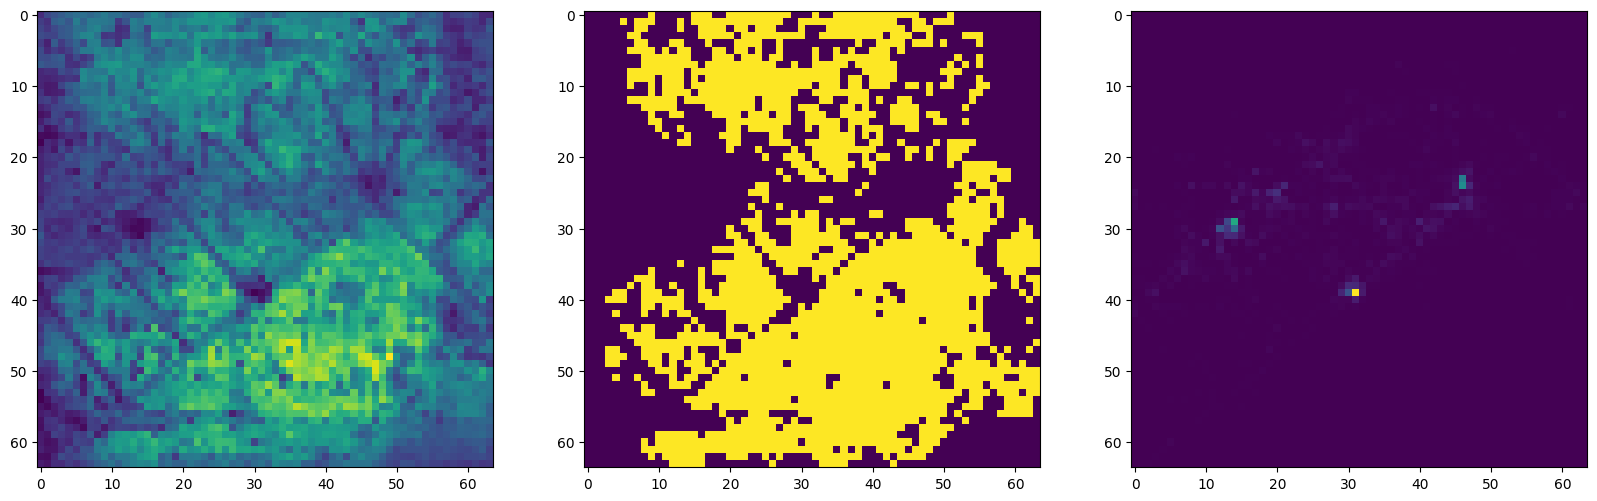

In [ ]:
head=0
layer=1
p2i_q = TwoWayTransformerObserver.attention_score['p2i_q'][layer]
p2i_k = TwoWayTransformerObserver.attention_score['p2i_k'][layer]
scores = cal_density(p2i_k,margin=0.96)
score_map=scores.mean(1)
fig,ax=plt.subplots(1,3,figsize=(20,15))

ax[0].imshow(score_map.reshape(64,64).cpu().detach().numpy())
score_map=torch.where(score_map>score_map.mean(-1,keepdim=True),1,0)
ax[1].imshow(score_map.reshape(64,64).cpu().detach().numpy())
ax[2].imshow(TwoWayTransformerObserver.attention_score['p2i_attn'][layer][:,head,:].mean(1).reshape(64,64).cpu().detach().numpy())

torch.Size([1, 8, 4096, 4096])


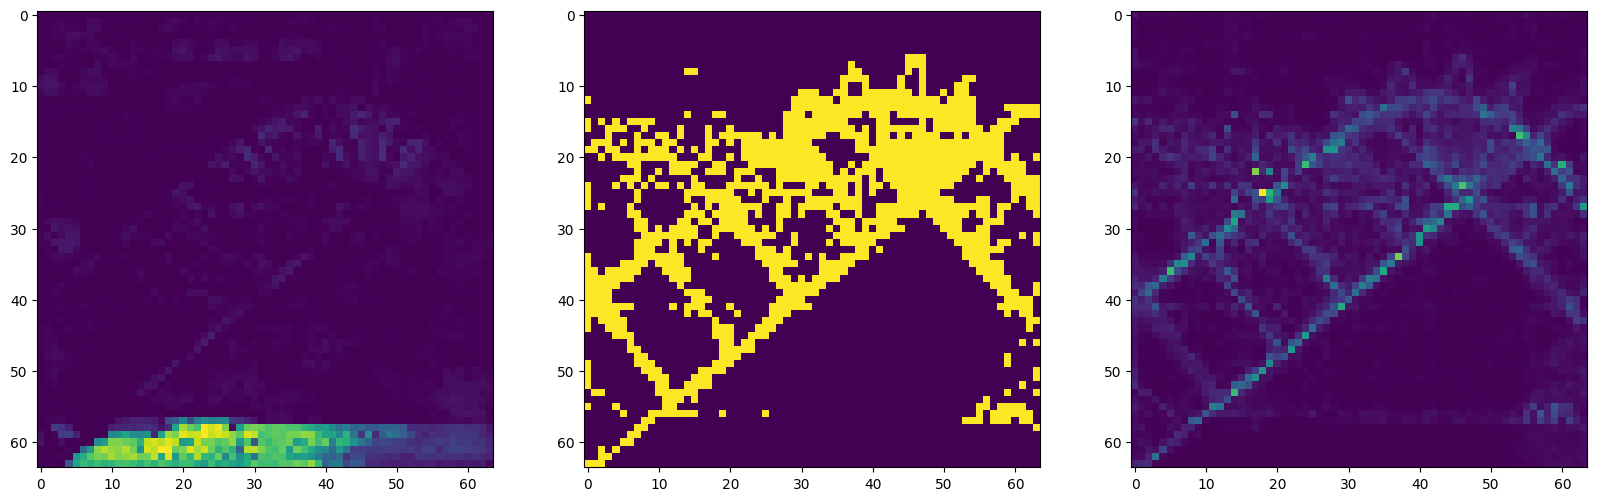

In [ ]:

head=0
p2i_q = TwoWayTransformerObserver.attention_score['final_q']
p2i_k = TwoWayTransformerObserver.attention_score['final_k']
attn_map = TwoWayTransformerObserver.attention_score['final_attn'].mean(1).mean(1)

scores = cal_density(p2i_k,margin=0.96)

score_map=scores.mean(1)
fig,ax=plt.subplots(1,3,figsize=(20,15))


ax[0].imshow(score_map.reshape(64,64).cpu().detach().numpy())
# mask=torch.where(score_map>score_map.mean(-1,keepdim=True),1,0)
mask=torch.where(attn_map>attn_map.mean(-1,keepdim=True),1,0)

ax[1].imshow(mask.reshape(64,64).cpu().detach().numpy())
ax[2].imshow(attn_map.reshape(64,64).cpu().detach().numpy())

In [ ]:


p2i_q =p2i_q.reshape(1, -1, 128)
p2i_k_high=p2i_k.permute(2,0,1,3)[mask.squeeze().nonzero()].squeeze(1).permute(1,0,2,3)
p2i_k_low=p2i_k.permute(2,0,1,3)[(1-mask).squeeze().nonzero()].squeeze(1).permute(1,0,2,3)
# diff =processor.stat['mask_decoder.transformer.final_attn_token_to_image']['diff']
# order =processor.stat['mask_decoder.transformer.final_attn_token_to_image']['order']

In [ ]:
p2i_k_high.shape

torch.Size([1, 1111, 8, 16])

In [ ]:
i2p_q = TwoWayTransformerObserver.attention_score['i2p_q'][1]
i2p_k = TwoWayTransformerObserver.attention_score['i2p_k'][1]
# attn_map = TwoWayTransformerObserver.attention_score['i2p_attn'].mean(1).mean(1)

In [ ]:
i2p_k

tensor([[[[ 6.1109, -5.0924, -5.0924,  ...,  3.0554, -4.0739, -6.1109],
          [ 5.7217, -5.7217, -5.7217,  ...,  3.8144, -4.7680, -5.7217],
          [ 5.8853, -4.9044, -5.8853,  ...,  3.9235, -4.9044, -5.8853],
          ...,
          [ 6.7165, -3.8380, -5.7570,  ...,  5.7570, -4.7975, -5.7570],
          [ 5.8703, -3.9135, -6.8486,  ...,  4.8919, -4.8919, -3.9135],
          [ 5.3203, -7.4484, -6.3843,  ...,  5.3203, -3.1922, -5.3203]],

         [[ 5.2302, -4.1842, -6.2763,  ...,  6.2763,  4.1842, -4.1842],
          [ 4.3370, -4.3370, -7.5897,  ...,  5.4212,  5.4212, -3.2527],
          [ 5.0200, -5.0200, -5.0200,  ...,  6.0240,  4.0160, -5.0200],
          ...,
          [ 4.9362, -5.9234, -1.9745,  ...,  6.9107,  3.9490, -2.9617],
          [ 6.5838, -5.6433, -1.8811,  ...,  4.7027,  5.6433, -3.7622],
          [ 4.2379, -4.2379, -9.8885,  ...,  5.6506,  5.6506, -2.8253]],

         [[-6.4429,  4.2953, -7.5167,  ..., -3.2215,  2.1476, -3.2215],
          [-6.2934,  5.2445, -

In [ ]:
# diff_new = torch.gather(diff.reshape(8,-1), index=order, dim=-1)
# p2i_k_high_reorder = torch.gather(p2i_k_high, index=order[None, None,...].expand(p2i_k_high.shape), dim=-1 )
# p2i_k_low_reorder = torch.gather(p2i_k_low, index=order[None, None,...].expand(p2i_k_low.shape), dim=-1 )

In [ ]:
p2i_k.shape

torch.Size([1, 8, 4096, 16])

In [ ]:
p2i_k_mean = p2i_k.mean(-2,keepdim=True).reshape(-1, 128)

In [ ]:
p2i_k_mean.shape

torch.Size([1, 128])

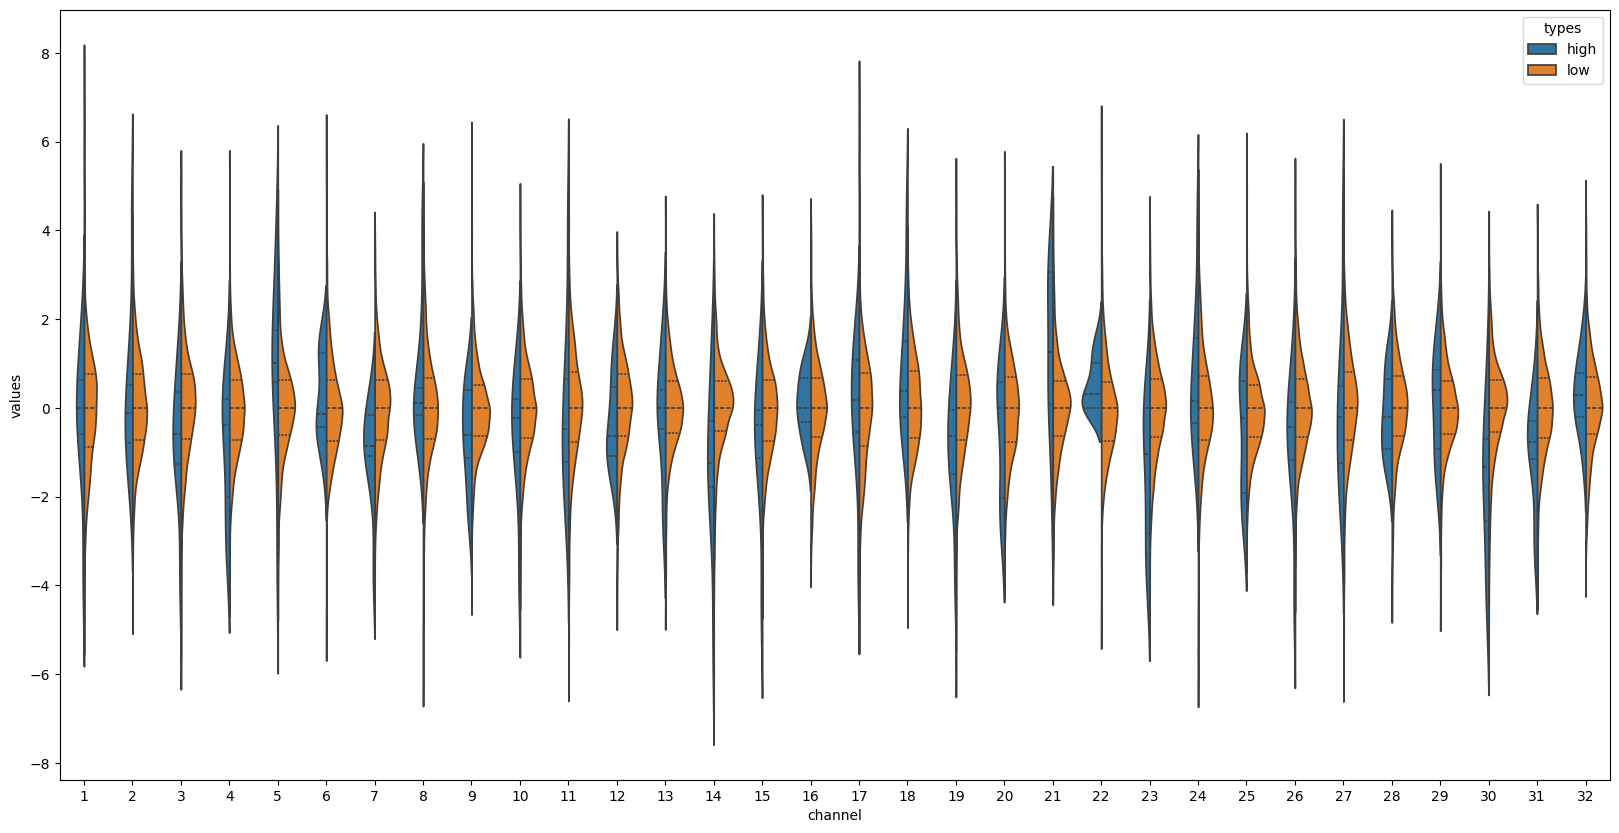

In [68]:
fig, ax= plt.subplots(1,1, figsize=(20,10))
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff)
get_activation_boxplot(high_activations=p2i_q.reshape(-1,128)/2, low_activations=(p2i_k.reshape(-1,128))*2, ax=ax, offset=0, max_channels=32,token_wise=False)

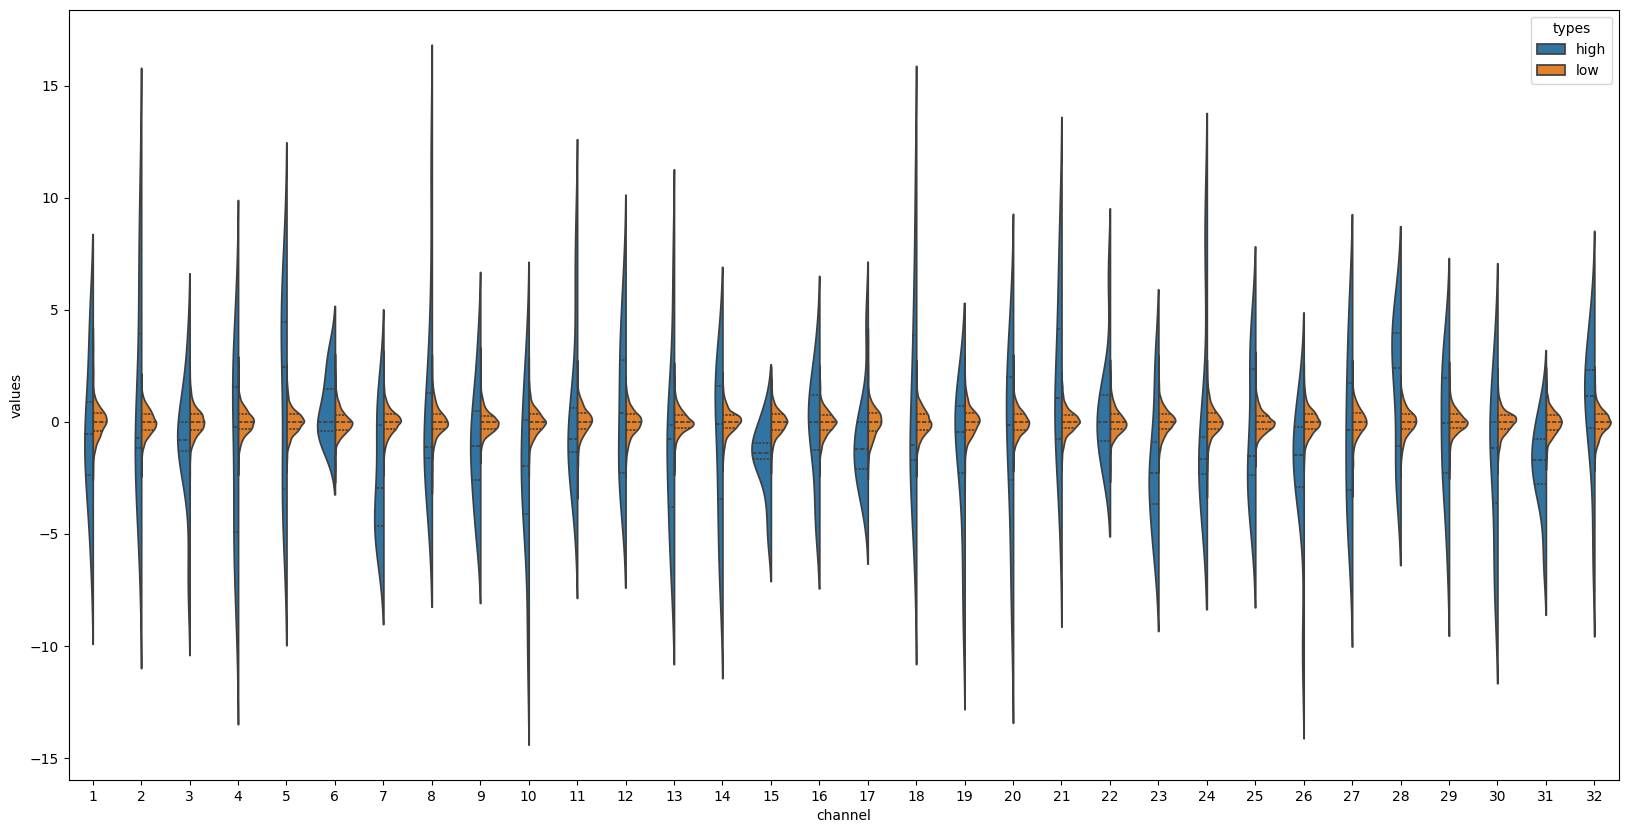

In [69]:
fig, ax= plt.subplots(1,1, figsize=(20,10))
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff)
get_activation_boxplot(high_activations=p2i_q.reshape(-1,128), low_activations=(p2i_k.reshape(-1,128)), ax=ax, offset=96, max_channels=32,token_wise=False)
# get_activation_boxplot(high_activations=p2i_q.reshape(-1,128), low_activations=(p2i_k_high.reshape(-1,128)-p2i_k_mean), ax=ax, offset=0, max_channels=32,token_wise=False)
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff_new.reshape(-1, 128))
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff_new.reshape(-1, 128))
# get_activation_boxplot(high_activations=(i2p_q).reshape(-1,128), low_activations=(i2p_k).reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False)

In [70]:
# get_activation_boxplot(high_activations=p2i_q/2, low_activations=2*p2i_k_high, ax=ax, offset=0, max_channels=32,token_wise=False)
# get_activation_boxplot(high_activations=p2i_q/2, low_activations=2*p2i_k_low, ax=ax, offset=0, max_channels=32,token_wise=False)

In [65]:
TwoWayTransformerObserver.clear_dict()